In [1]:
import tensorflow as tf 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
from tensorflow.keras.utils import image_dataset_from_directory

Data Preparation

In [3]:
training_set = image_dataset_from_directory(
    "C:/Users/priya/OneDrive/Desktop/3RD YEAR PROJECT/MobileNetV3/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 2737 files belonging to 3 classes.


In [4]:
validation_set = image_dataset_from_directory(
    "C:/Users/priya/OneDrive/Desktop/3RD YEAR PROJECT/MobileNetV3/val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 342 files belonging to 3 classes.


In [5]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

In [6]:
INPUT_SHAPE = (224,224,3)

In [7]:
mobnet = tf.keras.applications.MobileNetV3Small(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    # name="MobileNetV3Small",
)

In [8]:
#If you want to perform transfer learning then execute this celll
# mobnet.trainable = False #-- used to freeze weights of this pretrained model

In [9]:
model = tf.keras.models.Sequential()

In [10]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [11]:
model.add(mobnet)

In [12]:
model.add(tf.keras.layers.Dense(units = 3, activation="softmax"))

In [13]:
metrics_list = ["accuracy", tf.keras.metrics.F1Score()]

In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="categorical_crossentropy",metrics=metrics_list)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 1000)           │     2,554,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,557,971 (9.76 MB)

 Trainable params: 2,545,859 (9.71 MB)

 Non-trainable params: 12,112 (47.31 KB)

In [18]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 461ms/step - accuracy: 0.7654 - f1_score: 0.7636 - loss: 1.0624 - val_accuracy: 0.7427 - val_f1_score: 0.7257 - val_loss: 1.0603
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.9193 - f1_score: 0.9209 - loss: 1.0240 - val_accuracy: 0.8158 - val_f1_score: 0.8055 - val_loss: 1.0339
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 506ms/step - accuracy: 0.9503 - f1_score: 0.9508 - loss: 1.0085 - val_accuracy: 0.8158 - val_f1_score: 0.8039 - val_loss: 1.0270
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 490ms/step - accuracy: 0.9700 - f1_score: 0.9707 - loss: 0.9946 - val_accuracy: 0.8421 - val_f1_score: 0.8355 - val_loss: 1.0130
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 495ms/step - accuracy: 0.9759 - f1_score: 0.9762 - loss: 0.9811 - val_accuracy: 0.8012 - val_f1_score: 0.7910 - val_loss: 1.0068
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 476ms/step - accuracy: 0.9825 - f1_score: 0.9826 - loss: 0.9672 - val_accuracy: 0.8246 - val_f1_score: 

In [20]:
model.save("./Trained_Eye_disease_model.h5")
model.save("./Trained_Eye_disease_model.keras")

In [23]:
training_history.history

{'accuracy': [0.765436589717865,
  0.9192546606063843,
  0.9503105878829956,
  0.9700402021408081,
  0.9758859872817993,
  0.9824625253677368,
  0.981001079082489,
  0.9879429936408997,
  0.9905005693435669,
  0.9934234619140625,
  0.9930580854415894,
  0.9945195317268372,
  0.9926927089691162,
  0.9963463544845581,
  0.995980978012085],
 'f1_score': [array([0.75413847, 0.7596795 , 0.7769722 ], dtype=float32),
  array([0.9044879, 0.9450261, 0.9130434], dtype=float32),
  array([0.94064945, 0.96088654, 0.95078915], dtype=float32),
  array([0.9653274, 0.9796186, 0.9672285], dtype=float32),
  array([0.9720241 , 0.9810084 , 0.97551787], dtype=float32),
  array([0.9815016, 0.9841479, 0.9820924], dtype=float32),
  array([0.97983646, 0.98229504, 0.9810785 ], dtype=float32),
  array([0.98804337, 0.9908136 , 0.9857819 ], dtype=float32),
  array([0.9891422 , 0.9908136 , 0.99146104], dtype=float32),
  array([0.99347824, 0.9934296 , 0.9933712 ], dtype=float32),
  array([0.9929386, 0.9921259, 0.9938

In [24]:
#Saving history
import pickle
with open("training_history.pkl","wb") as f:
    pickle.dump(training_history.history,f)

In [28]:
#Reloding History from pickle file
import pickle
with open("Training_history.pkl","rb") as f:
    load_history = pickle.load(f)
print(load_history)

{'accuracy': [0.765436589717865, 0.9192546606063843, 0.9503105878829956, 0.9700402021408081, 0.9758859872817993, 0.9824625253677368, 0.981001079082489, 0.9879429936408997, 0.9905005693435669, 0.9934234619140625, 0.9930580854415894, 0.9945195317268372, 0.9926927089691162, 0.9963463544845581, 0.995980978012085], 'f1_score': [array([0.75413847, 0.7596795 , 0.7769722 ], dtype=float32), array([0.9044879, 0.9450261, 0.9130434], dtype=float32), array([0.94064945, 0.96088654, 0.95078915], dtype=float32), array([0.9653274, 0.9796186, 0.9672285], dtype=float32), array([0.9720241 , 0.9810084 , 0.97551787], dtype=float32), array([0.9815016, 0.9841479, 0.9820924], dtype=float32), array([0.97983646, 0.98229504, 0.9810785 ], dtype=float32), array([0.98804337, 0.9908136 , 0.9857819 ], dtype=float32), array([0.9891422 , 0.9908136 , 0.99146104], dtype=float32), array([0.99347824, 0.9934296 , 0.9933712 ], dtype=float32), array([0.9929386, 0.9921259, 0.9938359], dtype=float32), array([0.99457693, 0.993438

In [29]:
load_history.keys()

dict_keys(['accuracy', 'f1_score', 'loss', 'val_accuracy', 'val_f1_score', 'val_loss'])

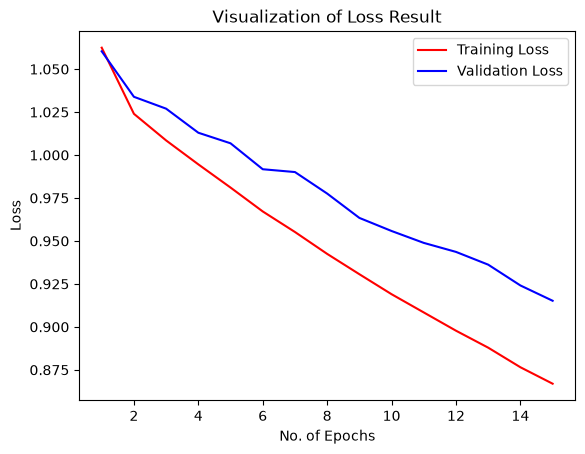

In [31]:
#Loss Visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs, load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()


## Model Evaluation

In [32]:
path = r"C:\Users\priya\OneDrive\Desktop\3RD YEAR PROJECT\Dataset\val\Trained_Eye_disease_model.h5"

import os
print(os.path.exists(path))

False


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 1000)           │     2,554,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,649,691 (29.18 MB)

 Trainable params: 2,545,859 (9.71 MB)

 Non-trainable params: 12,112 (47.31 KB)

 Optimizer params: 5,091,720 (19.42 MB)

In [35]:
test_set = image_dataset_from_directory(
    "C:/Users/priya/OneDrive/Desktop/3RD YEAR PROJECT/MobileNetV3/test",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 342 files belonging to 3 classes.


In [36]:
test_loss,test_acc,f1_score = model.evaluate(test_set)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9152 - f1_score: 0.9149 - loss: 0.8940


In [37]:
test_loss,test_acc,f1_score

(0.8940263986587524,
 0.9152047038078308,
 array([0.9       , 0.9222798 , 0.92250913], dtype=float32))

In [38]:
#Computing True label from test set
true_categories = tf.concat([y for x,y in test_set],axis=0)
Y_true = tf.argmax(true_categories,axis=1)

In [39]:
true_categories

<tf.Tensor: shape=(342, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], shape=(342, 3), dtype=float32)>

In [41]:
Y_true

<tf.Tensor: shape=(342,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
     

In [42]:
#Computing Predicted labels using test_set
predicted_categories = model.predict(test_set)
predicted_categories

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step


array([[0.41860533, 0.2884457 , 0.29294902],
       [0.41860533, 0.2884457 , 0.29294902],
       [0.41860533, 0.2884457 , 0.29294902],
       ...,
       [0.28675088, 0.2638063 , 0.44944283],
       [0.2867993 , 0.26382157, 0.44937918],
       [0.2867508 , 0.26380628, 0.4494429 ]],
      shape=(342, 3), dtype=float32)

In [43]:
Y_Pred = tf.argmax(predicted_categories,axis=1)
Y_Pred

<tf.Tensor: shape=(342,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0,
       2, 1, 1, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0,
       1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
     

## MobileNetV3 Classification Report   

In [45]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_Pred))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       115
           1       0.91      0.94      0.92        95
           2       0.90      0.95      0.92       132

    accuracy                           0.92       342
   macro avg       0.92      0.91      0.91       342
weighted avg       0.92      0.92      0.91       342



## Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_Pred)
cm

array([[ 99,   6,  10],
       [  2,  89,   4],
       [  4,   3, 125]])

<function matplotlib.pyplot.show(close=None, block=None)>

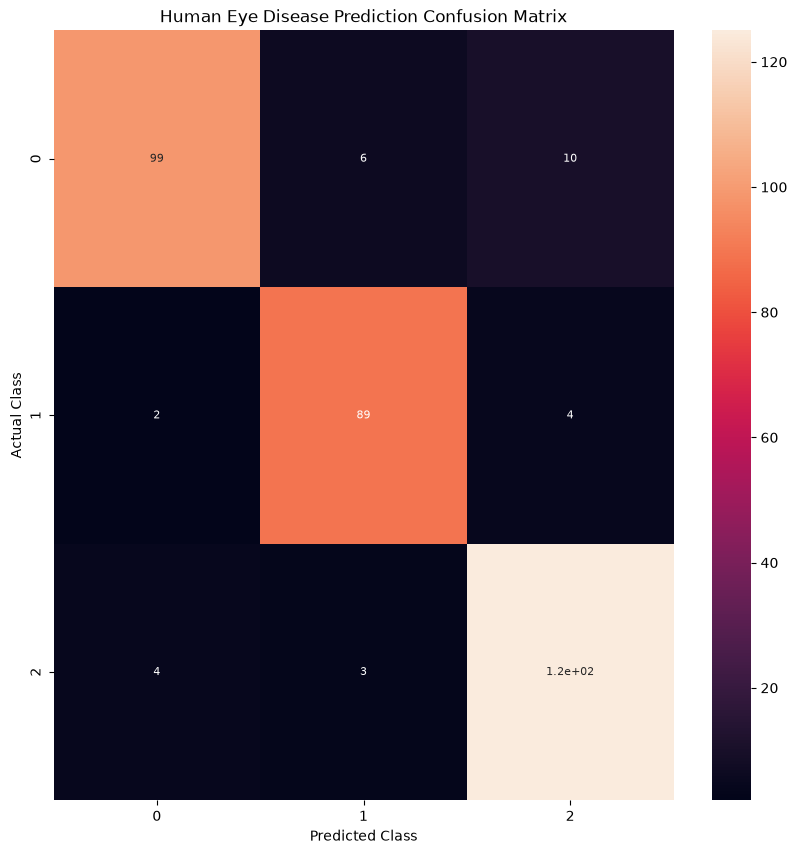

In [49]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show